In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adityachaudhary10/hippocampal-dataset/Task520_HarP/dataset.json
/kaggle/input/datasets/adityachaudhary10/hippocampal-dataset/Task520_HarP/labelTr/HarP_077.nii
/kaggle/input/datasets/adityachaudhary10/hippocampal-dataset/Task520_HarP/labelTr/HarP_025.nii
/kaggle/input/datasets/adityachaudhary10/hippocampal-dataset/Task520_HarP/labelTr/HarP_050.nii
/kaggle/input/datasets/adityachaudhary10/hippocampal-dataset/Task520_HarP/labelTr/HarP_027.nii
/kaggle/input/datasets/adityachaudhary10/hippocampal-dataset/Task520_HarP/labelTr/HarP_002.nii
/kaggle/input/datasets/adityachaudhary10/hippocampal-dataset/Task520_HarP/labelTr/HarP_084.nii
/kaggle/input/datasets/adityachaudhary10/hippocampal-dataset/Task520_HarP/labelTr/HarP_078.nii
/kaggle/input/datasets/adityachaudhary10/hippocampal-dataset/Task520_HarP/labelTr/HarP_068.nii
/kaggle/input/datasets/adityachaudhary10/hippocampal-dataset/Task520_HarP/labelTr/HarP_034.nii
/kaggle/input/datasets/adityachaudhary10/hippocampal-datas

In [2]:
import numpy as np
import nibabel as nib
import os
from glob import glob
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from scipy.spatial.distance import directed_hausdorff, cdist
from scipy.ndimage import binary_erosion, zoom, label
from scipy.ndimage import binary_opening, binary_closing
import h5py
# import streamlit as st
# from pathlib import Path

DATASET_DIR = '/kaggle/input/datasets/adityachaudhary10/hippocampal-dataset/Task520_HarP'

In [3]:
image_paths = glob("/kaggle/input/datasets/adityachaudhary10/hippocampal-dataset/Task520_HarP/imageTr/*")
label_paths = glob("/kaggle/input/datasets/adityachaudhary10/hippocampal-dataset/Task520_HarP/labelTr/*")

print(f"Found {len(image_paths)} images and {len(label_paths)} labels.")

Found 135 images and 135 labels.


In [4]:
np.random.seed(42)
idx = np.arange(len(image_paths))
np.random.shuffle(idx)

split = int(0.8 * len(idx))
train_idx = idx[:split]
val_idx   = idx[split:]

train_images = [image_paths[i] for i in train_idx]
train_labels = [label_paths[i] for i in train_idx]

val_images = [image_paths[i] for i in val_idx]
val_labels = [label_paths[i] for i in val_idx]

print(f"Training: {len(train_images)}, Validation: {len(val_images)}")

Training: 108, Validation: 27


In [5]:
def normalize(img):
    """Per-volume Z-score normalization"""
    return (img - img.mean()) / (img.std() + 1e-8)

In [6]:
class HarP3DDataset(Dataset):
    """Full 3D volume dataset for Hippocampus segmentation"""
    def __init__(self, image_paths, label_paths):
        self.image_paths = image_paths
        self.label_paths = label_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = nib.load(self.image_paths[idx]).get_fdata()
        lbl = nib.load(self.label_paths[idx]).get_fdata()

        img = normalize(img)
        lbl = (lbl > 0).astype(np.float32)

        # Add channel dimension
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        lbl = torch.tensor(lbl, dtype=torch.float32).unsqueeze(0)

        return img, lbl

In [7]:
train_ds = HarP3DDataset(train_images, train_labels)
val_ds   = HarP3DDataset(val_images, val_labels)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)  # batch=1 for full 3D volumes
val_loader   = DataLoader(val_ds, batch_size=1)

print(f"Training samples: {len(train_loader)}, Validation samples: {len(val_loader)}")

Training samples: 108, Validation samples: 27


In [8]:
class UNet3D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[32, 64, 128, 256]):
        super().__init__()

        self.encoders = nn.ModuleList()
        self.decoders = nn.ModuleList()
        self.pool = nn.MaxPool3d(2)

        # Encoder
        for feature in features:
            self.encoders.append(self.double_conv(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = self.double_conv(features[-1], features[-1]*2)

        # Decoder
        for feature in reversed(features):
            self.decoders.append(nn.ConvTranspose3d(feature*2, feature, kernel_size=2, stride=2))
            self.decoders.append(self.double_conv(feature*2, feature))

        self.final_conv = nn.Conv3d(features[0], out_channels, kernel_size=1)

    def double_conv(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        skip_connections = []

        for enc in self.encoders:
            x = enc(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.decoders), 2):
            x = self.decoders[idx](x)
            skip_conn = skip_connections[idx//2]
            if x.shape != skip_conn.shape:
                x = F.interpolate(x, size=skip_conn.shape[2:])
            x = torch.cat((skip_conn, x), dim=1)
            x = self.decoders[idx+1](x)

        return self.final_conv(x)

In [9]:
def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-5
    inter = (pred * target).sum()
    return 1 - (2*inter + smooth) / (pred.sum() + target.sum() + smooth)

In [10]:
def hd95(pred_mask, gt_mask):
    pred_points = np.argwhere(pred_mask > 0)
    gt_points = np.argwhere(gt_mask > 0)

    if len(pred_points) == 0 or len(gt_points) == 0:
        return np.nan

    d_matrix = cdist(pred_points, gt_points)
    d_pred_to_gt = d_matrix.min(axis=1)
    d_gt_to_pred = d_matrix.min(axis=0)

    return np.percentile(np.concatenate([d_pred_to_gt, d_gt_to_pred]), 95)

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet3D().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = int(input("Enter how many Epochs should happen: "))

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    hd_vals = []

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)  # x: [B,1,D,H,W], y: [B,1,D,H,W]
        optimizer.zero_grad()

        pred = model(x)  # output: [B,1,D,H,W]
        loss = dice_loss(pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        # Compute HD95 for each sample in the batch
        pred_sig = torch.sigmoid(pred).detach().cpu().numpy()  # [B,1,D,H,W]
        y_np = y.cpu().numpy()                                 # [B,1,D,H,W]

        for b in range(pred_sig.shape[0]):
            pred_mask = (pred_sig[b,0] > 0.5).astype(np.uint8)
            gt_mask = (y_np[b,0] > 0.5).astype(np.uint8)
            hd_val = hd95(pred_mask, gt_mask)
            if not np.isnan(hd_val):
                hd_vals.append(hd_val)

    mean_hd = np.nan if len(hd_vals) == 0 else np.mean(hd_vals)
    print(f"Epoch {epoch+1:03d} | Train Dice Loss: {train_loss/len(train_loader):.4f} | Hausdorff Distance (HD95): {mean_hd:.4f} mm")

Enter how many Epochs should happen:  100


Epoch 001 | Train Dice Loss: 0.9012 | Hausdorff Distance (HD95): 8.0861 mm
Epoch 002 | Train Dice Loss: 0.6007 | Hausdorff Distance (HD95): 1.9876 mm
Epoch 003 | Train Dice Loss: 0.2496 | Hausdorff Distance (HD95): 1.2782 mm
Epoch 004 | Train Dice Loss: 0.1722 | Hausdorff Distance (HD95): 1.1054 mm
Epoch 005 | Train Dice Loss: 0.1528 | Hausdorff Distance (HD95): 1.1011 mm
Epoch 006 | Train Dice Loss: 0.1406 | Hausdorff Distance (HD95): 1.0928 mm
Epoch 007 | Train Dice Loss: 0.1355 | Hausdorff Distance (HD95): 1.0934 mm
Epoch 008 | Train Dice Loss: 0.1320 | Hausdorff Distance (HD95): 1.0899 mm
Epoch 009 | Train Dice Loss: 0.1255 | Hausdorff Distance (HD95): 1.0809 mm
Epoch 010 | Train Dice Loss: 0.1235 | Hausdorff Distance (HD95): 1.0896 mm
Epoch 011 | Train Dice Loss: 0.1231 | Hausdorff Distance (HD95): 1.0923 mm
Epoch 012 | Train Dice Loss: 0.1210 | Hausdorff Distance (HD95): 1.0888 mm
Epoch 013 | Train Dice Loss: 0.1195 | Hausdorff Distance (HD95): 1.0864 mm
Epoch 014 | Train Dice Lo

In [12]:
os.makedirs("/kaggle/working", exist_ok=True)
torch.save(model.state_dict(), "/kaggle/working/unet3d.pth")

In [13]:
def infer_volume_3d(model, image_path):
    img = nib.load(image_path).get_fdata()
    img_norm = normalize(img)
    img_tensor = torch.tensor(img_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(img_tensor))
    pred_mask = (pred.cpu().numpy()[0,0] > 0.5).astype(np.uint8)
    return pred_mask, img.shape, nib.load(image_path).affine

In [14]:
def save_mask(mask, affine, out_path):
    nib.save(nib.Nifti1Image(mask, affine), out_path)

os.makedirs("/kaggle/working/pred_masks", exist_ok=True)

for img_path in val_images:
    mask, shape, affine = infer_volume_3d(model, img_path)
    fname = os.path.basename(img_path)
    save_mask(mask, affine, f"/kaggle/working/pred_masks/{fname}")

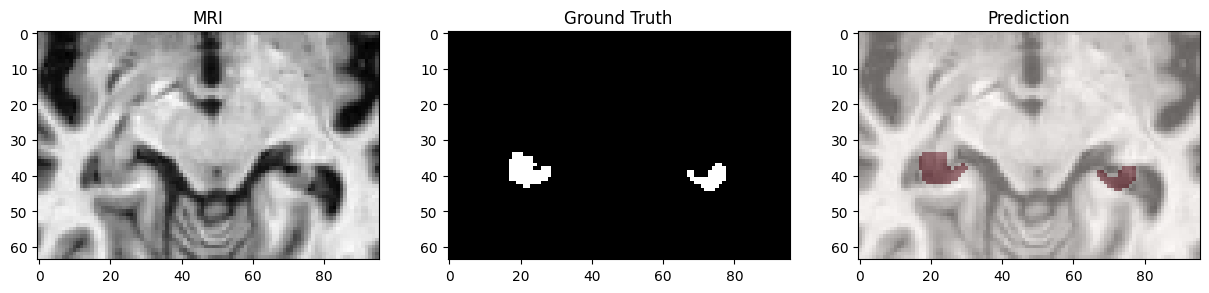

In [15]:
idx = 0  # first validation subject
mask, _, _ = infer_volume_3d(model, val_images[idx])
img = nib.load(val_images[idx]).get_fdata()
lbl = nib.load(val_labels[idx]).get_fdata()

slice_idx = mask.shape[0] // 2

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(img[slice_idx], cmap="gray")
plt.title("MRI")

plt.subplot(1,3,2)
plt.imshow(lbl[slice_idx], cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(img[slice_idx], cmap="gray")
plt.imshow(mask[slice_idx], alpha=0.4, cmap="Reds")
plt.title("Prediction")
plt.show()

In [16]:
dice_list, hd95_list = [], []

for img_path, lbl_path in zip(val_images, val_labels):

    # Get predicted binary mask (numpy)
    pred_mask, _, _ = infer_volume_3d(model, img_path)

    # Load GT mask (numpy)
    gt_mask = nib.load(lbl_path).get_fdata() > 0

    # Convert BOTH to torch tensors
    pred_tensor = torch.tensor(pred_mask, dtype=torch.float32)
    gt_tensor   = torch.tensor(gt_mask, dtype=torch.float32)

    # Add channel dimension to match training format if needed
    # Shape should be [1, D, H, W]
    pred_tensor = pred_tensor.unsqueeze(0)
    gt_tensor   = gt_tensor.unsqueeze(0)

    # Compute Dice LOSS (same function as training)
    dice = dice_loss(pred_tensor, gt_tensor).item()
    dice_list.append(dice)

    # HD95 (still numpy)
    hd_val = hd95(pred_mask, gt_mask)
    hd95_list.append(hd_val)

print("Mean Dice on Validation Set:", round(np.mean(dice_list), 4))
print("Mean Hausdorff Distance (HD95) on Validation Set:", round(np.nanmean(hd95_list), 4))

Mean Dice on Validation Set: 0.9625
Mean Hausdorff Distance (HD95) on Validation Set: 1.0153


In [17]:
for i, (d, hd) in enumerate(zip(dice_list, hd95_list)):
    print(f"Subject {i}: Dice = {d:.4f} | Hausdorff Distance (HD95) = {hd:.4f} mm")

Subject 0: Dice = 0.9722 | Hausdorff Distance (HD95) = 1.0000 mm
Subject 1: Dice = 0.9631 | Hausdorff Distance (HD95) = 1.0000 mm
Subject 2: Dice = 0.9713 | Hausdorff Distance (HD95) = 1.0000 mm
Subject 3: Dice = 0.9646 | Hausdorff Distance (HD95) = 1.0000 mm
Subject 4: Dice = 0.9678 | Hausdorff Distance (HD95) = 1.0000 mm
Subject 5: Dice = 0.9596 | Hausdorff Distance (HD95) = 1.0000 mm
Subject 6: Dice = 0.9673 | Hausdorff Distance (HD95) = 1.0000 mm
Subject 7: Dice = 0.9540 | Hausdorff Distance (HD95) = 1.0000 mm
Subject 8: Dice = 0.9640 | Hausdorff Distance (HD95) = 1.0000 mm
Subject 9: Dice = 0.9589 | Hausdorff Distance (HD95) = 1.0000 mm
Subject 10: Dice = 0.9501 | Hausdorff Distance (HD95) = 1.0000 mm
Subject 11: Dice = 0.9575 | Hausdorff Distance (HD95) = 1.0000 mm
Subject 12: Dice = 0.9728 | Hausdorff Distance (HD95) = 1.0000 mm
Subject 13: Dice = 0.9642 | Hausdorff Distance (HD95) = 1.0000 mm
Subject 14: Dice = 0.9488 | Hausdorff Distance (HD95) = 1.0000 mm
Subject 15: Dice = 0

In [18]:
print("Pred shape:", pred_mask.shape)
print("GT shape:", gt_mask.shape)

Pred shape: (64, 64, 96)
GT shape: (64, 64, 96)
